# Capstone Project Guide

This notebook is your runway into the **Regime-Shift: Macro-Aware Tactical Asset Allocation Engine** capstone. Every section is chosen because you will use it directly in the project: pulling multi-asset data, engineering features that describe *market regimes*, building and validating an HMM, and avoiding the single most common way quant projects quietly fail - **lookahead bias**.

**Sections**

1. Environment & imports
2. NumPy 
3. Pandas 
4. Feature engineering 
5. Matplotlib 
6. yfinance 
7. The lookahead bias problem (and why it kills backtests)
8. Walk-forward validation 
9. ML primer


---
## 1. Environment & Imports

Run this cell first. If any import fails, install the missing package with `pip install <package>` in a terminal (or `!pip install <package>` in a notebook cell) and re-run.

The project's tech stack is: `numpy`, `pandas`, `matplotlib`, `yfinance`, `scipy`, `hmmlearn`, `cvxpy`. We'll also touch `scikit-learn` and `torch` (PyTorch) since "ML" in the goals list extends beyond just HMMs. You'll want this for any feature-based classifiers or experimentation you do beyond the core HMM regime classifier.

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Market data
import yfinance as yf

# Stats / scientific
import scipy.stats as stats

# Will be used later in the notebook so install if missing:
# pip install hmmlearn scikit-learn torch cvxpy
try:
    from hmmlearn import hmm
    HMM_OK = True
except ImportError:
    HMM_OK = False
    print("hmmlearn not installed - install with `pip install hmmlearn` before Section 9")

try:
    import torch
    import torch.nn as nn
    TORCH_OK = True
except ImportError:
    TORCH_OK = False
    print("torch not installed - install with `pip install torch` before the PyTorch primer")

plt.rcParams["figure.figsize"] = (11, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

print("Environment ready.")


Environment ready.


---
## 2. NumPy

Pandas, scikit-learn, hmmlearn, and PyTorch are all built on top of NumPy arrays internally. When you call `.values` or `.to_numpy()` on a DataFrame, or when an HMM spits out a covariance matrix, you're in NumPy territory. You need fluency here for three reasons specific to this project:

1. **Vectorized math** — computing returns, log-returns, z-scores across thousands of rows without Python loops (loops are slow and, worse, easy to get subtly wrong with time-series data).
2. **Matrix operations** — covariance matrices, the core object in Markowitz-style optimization (`cvxpy` will consume these directly).
3. **Random state control** — HMMs are fit with random initializations; reproducibility requires you to understand `np.random.seed`.


In [2]:
# --- Arrays vs lists ---
prices_list = [100, 101, 99, 103, 105]
prices_arr = np.array(prices_list)

print(type(prices_list), type(prices_arr))
print(prices_arr * 1.1)        # vectorized — try this with a plain list, it breaks
print(prices_arr.mean(), prices_arr.std())


<class 'list'> <class 'numpy.ndarray'>
[110.  111.1 108.9 113.3 115.5]
101.6 2.1540659228538015


In [3]:
# --- Returns: the first transformation you'll do to ANY price series ---
prices = np.array([100, 102, 101, 105, 107, 104])

# simple returns
simple_returns = prices[1:] / prices[:-1] - 1

# log returns (preferred in quant work - additive across time, better statistical properties)
log_returns = np.diff(np.log(prices))

print("Simple returns:", np.round(simple_returns, 4))
print("Log returns:   ", np.round(log_returns, 4))

# Why log returns? They sum cleanly across time:
print("\nSum of log returns:", log_returns.sum())
print("Equivalent total log return:", np.log(prices[-1] / prices[0]))


Simple returns: [ 0.02   -0.0098  0.0396  0.019  -0.028 ]
Log returns:    [ 0.0198 -0.0099  0.0388  0.0189 -0.0284]

Sum of log returns: 0.039220713153280684
Equivalent total log return: 0.03922071315328133


In [4]:
# --- Matrices: covariance is the backbone of portfolio optimization ---
np.random.seed(42)

# simulate 3 correlated asset return streams (250 trading days)
n_days = 250
mean_returns = np.array([0.0005, 0.0003, 0.0001])   # equities, bonds, gold (daily)
cov_matrix = np.array([
    [0.00040, -0.00005,  0.00002],
    [-0.00005, 0.00010,  0.00001],
    [0.00002,  0.00001,  0.00015],
])

simulated_returns = np.random.multivariate_normal(mean_returns, cov_matrix, size=n_days)
print("Simulated returns shape:", simulated_returns.shape)

# recover the covariance matrix from data as this is what you'll do with REAL returns later
estimated_cov = np.cov(simulated_returns, rowvar=False)
print("\nEstimated covariance matrix:\n", np.round(estimated_cov, 6))


Simulated returns shape: (250, 3)

Estimated covariance matrix:
 [[ 3.25e-04 -3.00e-05  3.00e-06]
 [-3.00e-05  9.90e-05  3.00e-06]
 [ 3.00e-06  3.00e-06  1.53e-04]]


In [5]:
# --- Boolean masking: how you will isolate regime periods ---
returns = np.array([0.01, -0.02, 0.015, -0.03, 0.005, -0.01, 0.02])

# "Crisis" mask: any day with a loss worse than -1.5%
crisis_mask = returns < -0.015
print("Crisis days mask:", crisis_mask)
print("Crisis day returns:", returns[crisis_mask])
print("Average crisis-day return:", returns[crisis_mask].mean())

# This exact pattern - boolean mask -> subset -> aggregate -- is how you will compute
# regime-conditional statistics later (e.g. "average vol when HMM says Bear").


Crisis days mask: [False  True False  True False False False]
Crisis day returns: [-0.02 -0.03]
Average crisis-day return: -0.025


### Try it
1. Generate 500 simulated daily log-returns from `np.random.normal(0.0003, 0.012, 500)`.
2. Compute the annualized return (`mean * 252`) and annualized volatility (`std * sqrt(252)`).
3. Using boolean masking, isolate days where the return is in the bottom 5% (`np.percentile`) and compute their average. This is a crude proxy for "tail risk" you'll later assign to the Crisis regime.


In [ ]:
# Your code here


---
## 3. Pandas

If NumPy is the engine, Pandas is the dashboard. Every dataset in this project from equity prices, VIX to macro indicators arrive as a time-indexed table. Pandas' `DatetimeIndex` is what lets you align mismatched series (e.g. daily equities vs monthly CPI), resample frequencies, and shift data forward/backward in time which is *exactly* the skill that prevents lookahead bias.

Three pandas objects you must be fluent in:
- **Series** — one column, time-indexed (e.g. a single asset's daily returns)
- **DataFrame** — many columns sharing one time index (e.g. your multi-asset return matrix)
- **DatetimeIndex** — the index itself, which gives you `.resample()`, `.shift()`, `.rolling()`, `.expanding()`


In [6]:
# --- Building a time-indexed Series/DataFrame from scratch ---
dates = pd.date_range("2024-01-01", periods=10, freq="B")  # 'B' = business day frequency
prices = pd.Series([100, 101, 99, 103, 105, 104, 106, 108, 107, 110], index=dates, name="SPY")

print(prices)
print("\nIndex type:", type(prices.index))


2024-01-01    100
2024-01-02    101
2024-01-03     99
2024-01-04    103
2024-01-05    105
2024-01-08    104
2024-01-09    106
2024-01-10    108
2024-01-11    107
2024-01-12    110
Freq: B, Name: SPY, dtype: int64

Index type: <class 'pandas.DatetimeIndex'>


In [7]:
# --- Returns the pandas way ---
returns = prices.pct_change()          # simple returns
log_returns = np.log(prices).diff()    # log returns

df = pd.DataFrame({"price": prices, "simple_ret": returns, "log_ret": log_returns})
print(df)

# Note row 0 is NaN — there's no "previous day" to compute a return from.
# ALWAYS check for and handle these NaNs explicitly; silently dropping or
# filling them wrong is a classic source of subtle bugs.


            price  simple_ret   log_ret
2024-01-01    100         NaN       NaN
2024-01-02    101    0.010000  0.009950
2024-01-03     99   -0.019802 -0.020001
2024-01-04    103    0.040404  0.039609
2024-01-05    105    0.019417  0.019231
2024-01-08    104   -0.009524 -0.009569
2024-01-09    106    0.019231  0.019048
2024-01-10    108    0.018868  0.018692
2024-01-11    107   -0.009259 -0.009302
2024-01-12    110    0.028037  0.027652


In [8]:
# --- .shift(): the single most important method for avoiding lookahead bias ---
# shift(1) moves data FORWARD in time (i.e., "what I knew yesterday")
df["price_lagged_1"] = df["price"].shift(1)

# shift(-1) moves data BACKWARD — i.e. peeking into the FUTURE.
# You will use this ONLY when explicitly constructing a forward-looking
# TARGET for supervised learning, never as a FEATURE.
df["price_next_day"] = df["price"].shift(-1)

print(df[["price", "price_lagged_1", "price_next_day"]])


            price  price_lagged_1  price_next_day
2024-01-01    100             NaN           101.0
2024-01-02    101           100.0            99.0
2024-01-03     99           101.0           103.0
2024-01-04    103            99.0           105.0
2024-01-05    105           103.0           104.0
2024-01-08    104           105.0           106.0
2024-01-09    106           104.0           108.0
2024-01-10    108           106.0           107.0
2024-01-11    107           108.0           110.0
2024-01-12    110           107.0             NaN


In [9]:
# --- Aligning multiple assets on a shared time index ---
dates2 = pd.date_range("2024-01-01", periods=10, freq="B")
spy = pd.Series(np.random.normal(0.0005, 0.01, 10).cumsum() + 100, index=dates2, name="SPY")
tlt = pd.Series(np.random.normal(0.0001, 0.005, 10).cumsum() + 100, index=dates2, name="TLT")
gld = pd.Series(np.random.normal(0.0002, 0.008, 10).cumsum() + 100, index=dates2, name="GLD")

multi_asset = pd.concat([spy, tlt, gld], axis=1)
print(multi_asset)

multi_returns = multi_asset.pct_change().dropna()
print("\nReturns:\n", multi_returns)
print("\nCorrelation matrix:\n", multi_returns.corr())


                   SPY         TLT         GLD
2024-01-01   99.991268   99.997222  100.005862
2024-01-02   99.978251   99.997932  100.001562
2024-01-03   99.968992  100.010832  100.006822
2024-01-04   99.980029  100.010452  100.014802
2024-01-05   99.971035  100.016298  100.019976
2024-01-08   99.997858  100.012882  100.007615
2024-01-09  100.003292  100.012808  100.001998
2024-01-10  100.005640  100.021762  100.000217
2024-01-11   99.997556  100.018727   99.999822
2024-01-12  100.005059  100.027889  100.004987

Returns:
                  SPY           TLT       GLD
2024-01-02 -0.000130  7.100688e-06 -0.000043
2024-01-03 -0.000093  1.290069e-04  0.000053
2024-01-04  0.000110 -3.802583e-06  0.000080
2024-01-05 -0.000090  5.845756e-05  0.000052
2024-01-08  0.000268 -3.415325e-05 -0.000124
2024-01-09  0.000054 -7.493280e-07 -0.000056
2024-01-10  0.000023  8.952857e-05 -0.000018
2024-01-11 -0.000081 -3.034175e-05 -0.000004
2024-01-12  0.000075  9.160527e-05  0.000052

Correlation matrix:
 

In [10]:
# --- Resampling: changing frequency without breaking alignment ---
# Real macro data (CPI, GDP) is monthly/quarterly while equities are daily.
# resample() lets you convert one to match the other's frequency.

weekly_price = prices.resample("W").last()   # last price of each week
weekly_return = prices.resample("W").apply(lambda x: x.iloc[-1] / x.iloc[0] - 1)

print("Weekly closing price:\n", weekly_price)
print("\nWeekly return:\n", weekly_return)


Weekly closing price:
 2024-01-07    105
2024-01-14    110
Freq: W-SUN, Name: SPY, dtype: int64

Weekly return:
 2024-01-07    0.050000
2024-01-14    0.057692
Freq: W-SUN, Name: SPY, dtype: float64


### Try it
1. Build a DataFrame of 3 fake assets over 60 business days using `np.random.normal` cumulative sums (like above).
2. Compute daily log returns for all three.
3. Resample to **monthly** returns using `.resample("ME").apply(...)` (month-end compounding, not simple averaging — returns compound multiplicatively).
4. Compute the rolling 20-day correlation between asset 1 and asset 2 using `.rolling(20).corr()`. This rolling correlation idea will resurface as a regime-detection feature.


In [ ]:
# Your code here


---
## 4. Feature Engineering

This is the conceptual heart of the capstone. Any trading model or regime classifier doesnt really see the "the market", it sees whatever numerical features you feed it. The quality of your regime classification is bounded by the quality of these features. We'll build the three feature families almost every regime-detection model uses: **momentum**, **volatility**, and **window statistics** (rolling vs expanding), then talk about why each one is a meaningfully different signal.

### Why these three?

- **Momentum** captures *direction* — is the market trending or chopping?
- **Volatility** captures *uncertainty* — calm markets and crisis markets look very different even at the same price level.
- **Rolling/expanding windows** are *how* you compute both, and the window choice itself encodes an assumption about how fast regimes can change.

A regime classifier built only on price level would be nearly useless as price alone doesn't tell you if you're in a bull, bear, or crisis. The same price could be reached after a calm grind up or a violent crash-and-recover. Momentum + volatility, computed over multiple windows, is what actually discriminates these regimes.


In [11]:
# --- Get something real to work with ---
spy = yf.download("SPY", start="2015-01-01", end="2024-01-01", progress=False, auto_adjust=True)
spy = spy[["Close"]].rename(columns={"Close": "close"})
spy["log_ret"] = np.log(spy["close"]).diff()
spy = spy.dropna()
print(spy.head())
print(f"\n{len(spy)} trading days loaded")


Price            close   log_ret
Ticker             SPY          
Date                            
2015-01-05  166.623367 -0.018225
2015-01-06  165.053925 -0.009464
2015-01-07  167.110687  0.012384
2015-01-08  170.076111  0.017590
2015-01-09  168.713181 -0.008046

2263 trading days loaded


### 4.1 Momentum

Momentum measures the cumulative direction of price movement over a lookback window. The classic formulation is just the total return over N days:

$$\text{Momentum}_N(t) = \frac{P_t}{P_{t-N}} - 1$$

Different lookback windows pick up different things: a 5-day momentum is noisy short-term direction; a 126-day (6-month) momentum is closer to a macro trend signal. Using *multiple* momentum windows as separate features lets the HMM see both short-term flips and longer trend persistence simultaneously.


In [12]:
# --- Momentum at multiple horizons ---
for window in [5, 21, 63, 126]:   # ~1wk, 1mo, 1qtr, 6mo (in trading days)
    spy[f"mom_{window}d"] = spy["close"].pct_change(window)

print(spy[["close", "mom_5d", "mom_21d", "mom_63d", "mom_126d"]].tail(8))


Price            close    mom_5d   mom_21d   mom_63d  mom_126d
Ticker             SPY                                        
Date                                                          
2023-12-19  460.935028  0.027290  0.057621  0.086917  0.100030
2023-12-20  454.547791 -0.000726  0.034999  0.089869  0.080885
2023-12-21  458.857788  0.005522  0.047095  0.102682  0.099445
2023-12-22  459.779968  0.009205  0.045164  0.100272  0.106174
2023-12-26  461.721344  0.007797  0.048931  0.121392  0.098799
2023-12-27  462.556244  0.003517  0.052724  0.122972  0.100231
2023-12-28  462.730896  0.018003  0.052080  0.116920  0.096325
2023-12-29  461.391357  0.005521  0.049773  0.116396  0.080402


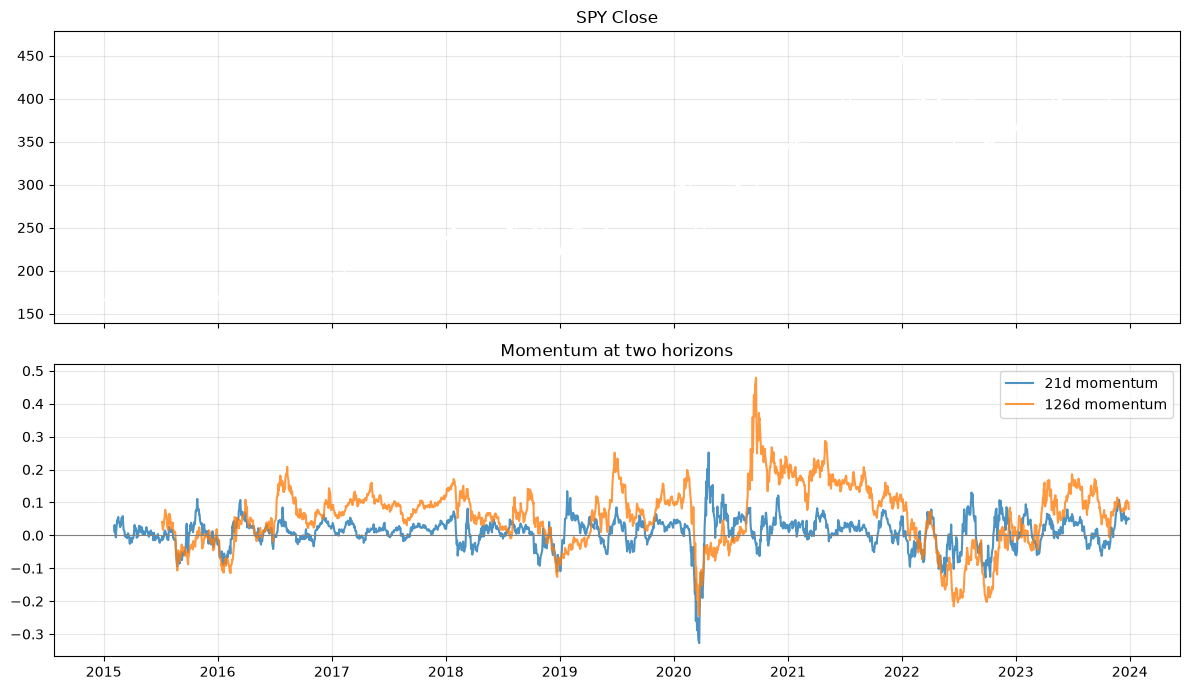

In [13]:
fig, ax = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
ax[0].plot(spy.index, spy["close"], color="white", lw=1)
ax[0].set_title("SPY Close")

ax[1].plot(spy.index, spy["mom_21d"], label="21d momentum", alpha=0.8)
ax[1].plot(spy.index, spy["mom_126d"], label="126d momentum", alpha=0.8)
ax[1].axhline(0, color="grey", lw=0.8)
ax[1].set_title("Momentum at two horizons")
ax[1].legend()
plt.tight_layout()
plt.show()


### 4.2 Volatility

Volatility is the single most important regime signal in practice — crisis periods are defined far more reliably by *volatility spikes* than by direction. The standard estimator is the rolling standard deviation of returns, annualized:

$$\sigma_N(t) = \text{std}(r_{t-N:t}) \times \sqrt{252}$$

Note: this uses *close-to-close* returns. More sophisticated estimators (Parkinson, Garman-Klass) use intraday high/low, which is more data-efficient — worth exploring once you've nailed the basics, but realized volatility from close prices is a perfectly good starting feature.


Price        log_ret    vol_5d   vol_21d   vol_63d
Ticker                                            
Date                                              
2023-12-19  0.006062  0.088313  0.071799  0.126076
2023-12-20 -0.013954  0.131818  0.089670  0.124612
2023-12-21  0.009437  0.148204  0.092424  0.125423
2023-12-22  0.002008  0.146191  0.092227  0.125311
2023-12-26  0.004214  0.144242  0.092338  0.120942
2023-12-27  0.001807  0.138927  0.091169  0.120908
2023-12-28  0.000378  0.056450  0.091317  0.120675
2023-12-29 -0.002899  0.041647  0.092570  0.120745


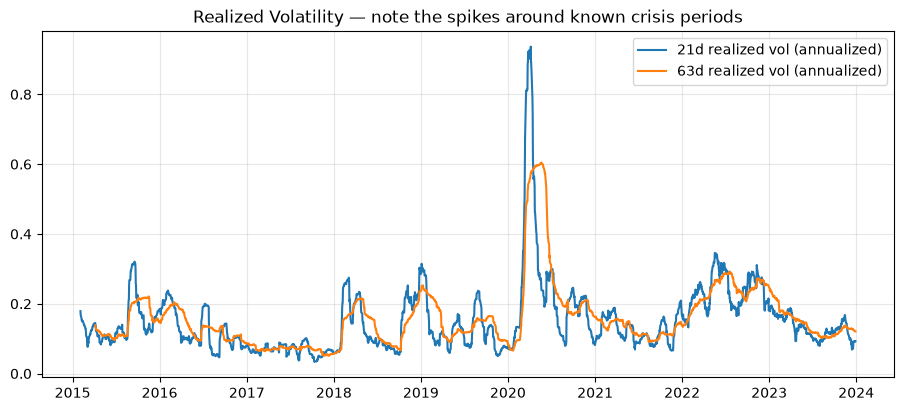

In [14]:
# --- Realized volatility at multiple horizons ---
for window in [5, 21, 63]:
    spy[f"vol_{window}d"] = spy["log_ret"].rolling(window).std() * np.sqrt(252)

print(spy[["log_ret", "vol_5d", "vol_21d", "vol_63d"]].tail(8))

fig, ax = plt.subplots()
ax.plot(spy.index, spy["vol_21d"], label="21d realized vol (annualized)")
ax.plot(spy.index, spy["vol_63d"], label="63d realized vol (annualized)")
ax.set_title("Realized Volatility — note the spikes around known crisis periods")
ax.legend()
plt.show()


### 4.3 Rolling vs Expanding Windows — and why the choice matters

This distinction is easy to gloss over but it shouldn't be as it directly determines what kind of bias you might introduce.

- **`.rolling(N)`** — a fixed-size window that slides forward. At any time `t` it only sees the last `N` observations. This is what you want for *regime-sensitive* features: volatility 5 years ago tells you nothing about whether today is calm or stressed.
- **`.expanding()`** — a window that starts at the beginning of your data and grows by one observation each step. Useful for things like "all-time average return up to today" or — critically — **for normalization statistics in walk-forward validation**, where you only want to use information available up to time `t`, using *all* of it, not just a fixed recent slice.

The trap: if you compute a feature using `.mean()` or `.std()` over the **entire dataset** (not rolling, not expanding-up-to-t) you've used future information to describe the past. That's lookahead bias, and Section 7 deals with it directly.


   value  rolling_mean_3  expanding_mean
0     10             NaN             NaN
1     12             NaN             NaN
2      9       10.333333       10.333333
3     15       12.000000       11.500000
4     20       14.666667       13.200000
5     18       17.666667       14.000000
6     14       17.333333       14.000000
7     22       18.000000       15.000000
8     19       18.333333       15.444444
9     25       22.000000       16.400000


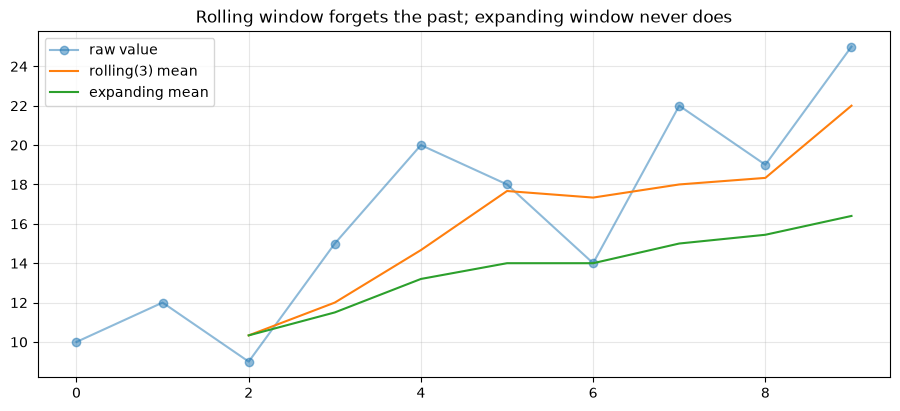

In [15]:
# --- Rolling vs expanding, side by side ---
toy = pd.Series([10, 12, 9, 15, 20, 18, 14, 22, 19, 25], name="value")

rolling_mean = toy.rolling(window=3).mean()
expanding_mean = toy.expanding(min_periods=3).mean()

comparison = pd.DataFrame({
    "value": toy,
    "rolling_mean_3": rolling_mean,
    "expanding_mean": expanding_mean,
})
print(comparison)

fig, ax = plt.subplots()
ax.plot(toy.index, toy, "o-", label="raw value", alpha=0.5)
ax.plot(toy.index, rolling_mean, label="rolling(3) mean")
ax.plot(toy.index, expanding_mean, label="expanding mean")
ax.legend()
ax.set_title("Rolling window forgets the past; expanding window never does")
plt.show()


### 4.4 Z-scoring features (and doing it correctly)

HMMs and most ML models are sensitive to feature scale for e.g. a volatility feature ranging 0.05–0.6 and a momentum feature ranging -0.3–0.3 need to be put on comparable scales, typically via z-scoring:

$$z_t = \frac{x_t - \mu}{\sigma}$$

**The trap, again:** if you compute `mu` and `sigma` using the full dataset's mean/std, you've leaked future information into every single row including the earliest ones. The correct approach in a walk-forward setting is to compute `mu`/`sigma` only from training data, or use an expanding/rolling window so that the z-score at time `t` only reflects information available *up to* `t`. We'll make this concrete in Section 7-8.


In [16]:
# WRONG - uses the entire series' stats, leaking the future into the past
spy["vol_21d_zscore_LEAKY"] = (
    (spy["vol_21d"] - spy["vol_21d"].mean()) / spy["vol_21d"].std()
)

# BETTER - expanding window, so z-score at time t only uses data up to t
roll_mean = spy["vol_21d"].expanding(min_periods=63).mean()
roll_std = spy["vol_21d"].expanding(min_periods=63).std()
spy["vol_21d_zscore_SAFE"] = (spy["vol_21d"] - roll_mean) / roll_std

print(spy[["vol_21d", "vol_21d_zscore_LEAKY", "vol_21d_zscore_SAFE"]].dropna().head(8))


Price        vol_21d vol_21d_zscore_LEAKY vol_21d_zscore_SAFE
Ticker                                                       
Date                                                         
2015-05-04  0.090832            -0.589513           -1.286556
2015-05-05  0.098317            -0.516466           -0.955751
2015-05-06  0.098995            -0.509850           -0.913929
2015-05-07  0.099266            -0.507208           -0.890156
2015-05-08  0.108049            -0.421501           -0.513064
2015-05-11  0.108101            -0.420996           -0.506158
2015-05-12  0.107394            -0.427891           -0.531473
2015-05-13  0.107214            -0.429646           -0.534286


### Try it
1. Build a momentum feature at a horizon of your choice (try 10 days) AND a volatility feature at the same horizon.
2. Plot both on twin axes (`ax2 = ax.twinx()`) to visually inspect: do volatility spikes tend to coincide with negative momentum? (This is the kind of inspection that justifies feeding both into the HMM as separate but related signals.)
3. Z-score your momentum feature using an **expanding** window with `min_periods=63`, and explain in a markdown cell why `min_periods` matters here (hint: what happens to a z-score computed from only 2 data points?).


In [ ]:
# Your code here


---
## 5. Matplotlib —

You will produce three kinds of plots constantly in this project: price/return time series, regime-overlay charts (price colored by hidden state), and backtest equity curves with drawdown shading. Matplotlib does all three without needing anything fancier.


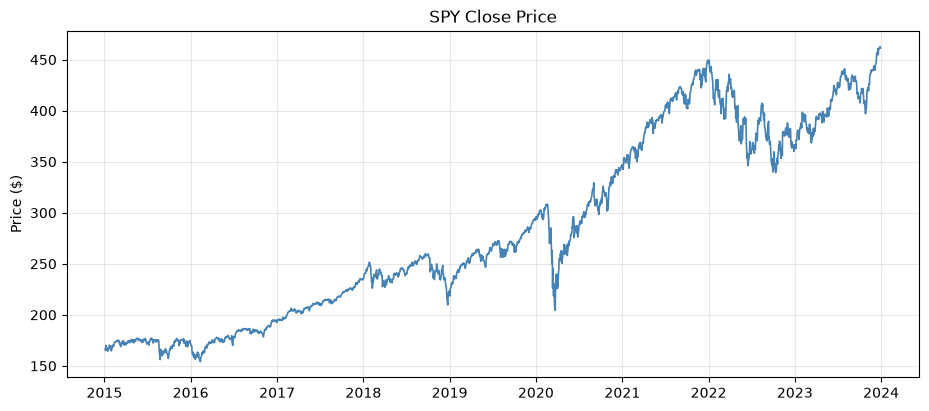

In [17]:
# --- Basic time series plot with proper date formatting ---
fig, ax = plt.subplots()
ax.plot(spy.index, spy["close"], color="steelblue", lw=1.2)
ax.set_title("SPY Close Price")
ax.set_ylabel("Price ($)")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
plt.show()


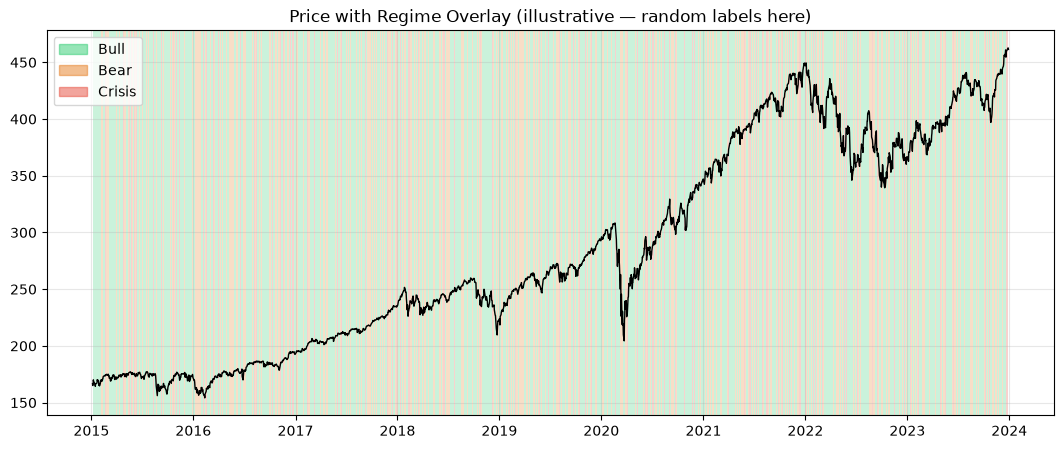

In [18]:
# --- Regime overlay using axvspan ---

# fake regime labels for demonstration: 0=Bull, 1=Bear, 2=Crisis
np.random.seed(1)
fake_regime = np.random.choice([0, 1, 2], size=len(spy), p=[0.6, 0.3, 0.1])
spy["fake_regime"] = fake_regime

regime_colors = {0: "#2ecc71", 1: "#e67e22", 2: "#e74c3c"}
regime_names = {0: "Bull", 1: "Bear", 2: "Crisis"}

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(spy.index, spy["close"], color="black", lw=1, zorder=3)

# shade contiguous blocks of the same regime
regime_vals = spy["fake_regime"].values
start_idx = 0
for i in range(1, len(regime_vals) + 1):
    if i == len(regime_vals) or regime_vals[i] != regime_vals[start_idx]:
        ax.axvspan(spy.index[start_idx], spy.index[min(i, len(regime_vals)-1)],
                   color=regime_colors[regime_vals[start_idx]], alpha=0.25, lw=0)
        start_idx = i

handles = [plt.Rectangle((0,0),1,1, color=c, alpha=0.5) for c in regime_colors.values()]
ax.legend(handles, regime_names.values(), loc="upper left")
ax.set_title("Price with Regime Overlay (illustrative — random labels here)")
plt.show()


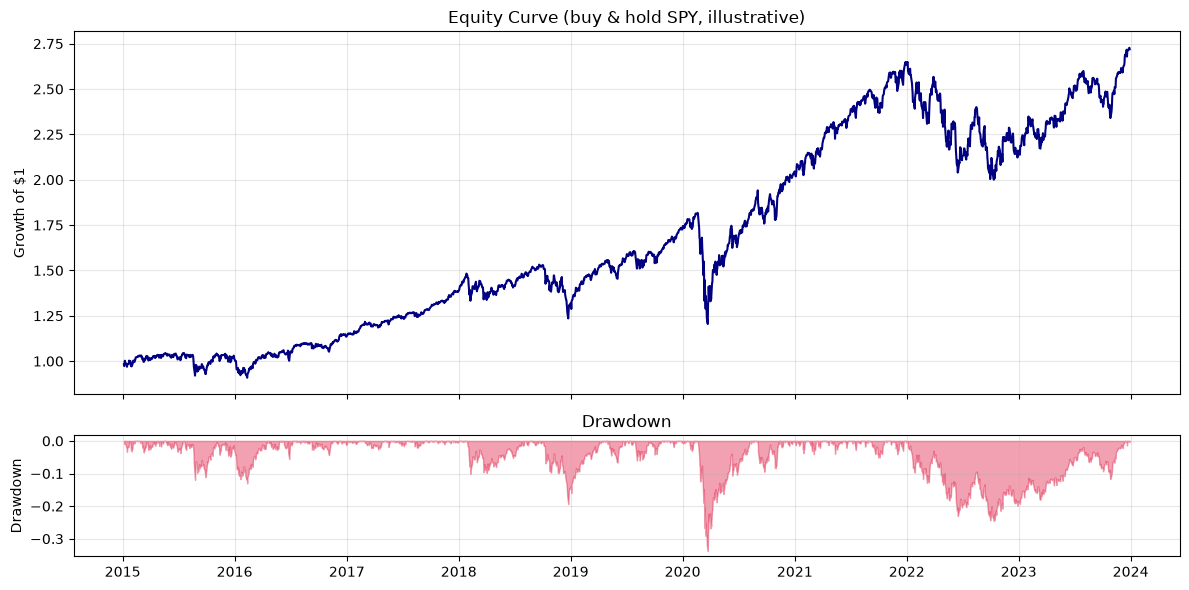

In [19]:
# --- Equity curve with drawdown subplot (your tear sheet needs this) ---
strategy_returns = spy["log_ret"].fillna(0)
equity_curve = np.exp(strategy_returns.cumsum())
running_max = equity_curve.cummax()
drawdown = equity_curve / running_max - 1

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True,
                           gridspec_kw={"height_ratios": [3, 1]})
axes[0].plot(equity_curve.index, equity_curve, color="navy")
axes[0].set_title("Equity Curve (buy & hold SPY, illustrative)")
axes[0].set_ylabel("Growth of $1")

axes[1].fill_between(drawdown.index, drawdown, 0, color="crimson", alpha=0.4)
axes[1].set_title("Drawdown")
axes[1].set_ylabel("Drawdown")
plt.tight_layout()
plt.show()


### Try it
Recreate the regime-overlay plot above but instead of random fake labels, define a simple **rule-based** "regime": label a day Crisis if `vol_21d_zscore_SAFE > 1.5`, Bear if `mom_21d < 0` (and not Crisis), else Bull. This is a hand-coded baseline regime classifier — useful to have before you trust the HMM's output, since you'll want something to sanity-check it against.


In [ ]:
# Your code here


---
## 6. yfinance

Your data sources list includes Yahoo Finance for multi-asset daily returns, FRED for macro indicators, and CBOE for VIX history. `yfinance` is your main workhorse for the first and last of those (VIX is available on Yahoo as the ticker `^VIX`). This section covers the patterns you'll reuse constantly: multi-ticker downloads, handling the MultiIndex columns yfinance returns, and aligning everything onto one clean DataFrame.


In [20]:
# --- Downloading multiple tickers at once ---
tickers = ["SPY", "TLT", "GLD", "^VIX"]   # equities, bonds, gold, vol index
raw = yf.download(tickers, start="2015-01-01", end="2024-01-01", progress=False, auto_adjust=True)

print(raw.columns)   # MultiIndex: (field, ticker)
print(raw.head())


MultiIndex([( 'Close',  'GLD'),
            ( 'Close',  'SPY'),
            ( 'Close',  'TLT'),
            ( 'Close', '^VIX'),
            (  'High',  'GLD'),
            (  'High',  'SPY'),
            (  'High',  'TLT'),
            (  'High', '^VIX'),
            (   'Low',  'GLD'),
            (   'Low',  'SPY'),
            (   'Low',  'TLT'),
            (   'Low', '^VIX'),
            (  'Open',  'GLD'),
            (  'Open',  'SPY'),
            (  'Open',  'TLT'),
            (  'Open', '^VIX'),
            ('Volume',  'GLD'),
            ('Volume',  'SPY'),
            ('Volume',  'TLT'),
            ('Volume', '^VIX')],
           names=['Price', 'Ticker'])
Price            Close                                          High                                           Low  \
Ticker             GLD         SPY        TLT       ^VIX         GLD         SPY        TLT       ^VIX         GLD   
Date                                                                                 

In [21]:
# --- Extracting just Close prices cleanly ---
close_prices = raw["Close"].copy()
close_prices.columns.name = None
close_prices = close_prices.rename(columns={"^VIX": "VIX"})
print(close_prices.head())
print("\nMissing values per column:\n", close_prices.isna().sum())


                   GLD         SPY        TLT        VIX
Date                                                    
2015-01-02  114.080002  169.687851  93.023720  17.790001
2015-01-05  115.800003  166.623367  94.484970  19.920000
2015-01-06  117.120003  165.053925  96.187340  21.120001
2015-01-07  116.430000  167.110687  95.997398  19.309999
2015-01-08  115.940002  170.076111  94.726051  17.010000

Missing values per column:
 GLD    0
SPY    0
TLT    0
VIX    0
dtype: int64


In [22]:
# --- Building your multi-asset returns matrix (the actual input to the HMM) ---
asset_prices = close_prices[["SPY", "TLT", "GLD"]]
asset_returns = np.log(asset_prices).diff().dropna()

vix_level = close_prices["VIX"]   # VIX is a LEVEL (an index value), not something you return-transform

# Align everything onto the SAME index — inner join drops any dates where one series is missing
master_df = asset_returns.join(vix_level, how="inner").dropna()
print(master_df.head())
print(f"\nFinal aligned dataset: {master_df.shape[0]} rows, {master_df.shape[1]} columns")


                 SPY       TLT       GLD        VIX
Date                                               
2015-01-05 -0.018225  0.015586  0.014965  19.920000
2015-01-06 -0.009464  0.017857  0.011334  21.120001
2015-01-07  0.012384 -0.001977 -0.005909  19.309999
2015-01-08  0.017590 -0.013332 -0.004217  17.010000
2015-01-09 -0.008046  0.010894  0.011321  17.549999

Final aligned dataset: 2263 rows, 4 columns


**A note on `auto_adjust`:** keep it `True` (default in recent yfinance) so prices are adjusted for dividends/splits — using unadjusted close prices for returns will inject fake jumps around dividend dates and split events, which is its own subtle bias.

**A note on missing data:** different exchanges have different holiday calendars, and tickers can have gaps for entirely mundane reasons (delisting, data vendor issues). Always inspect `.isna().sum()` after a join before moving on — silently propagating NaNs into an HMM `.fit()` call will either crash or, worse, silently degrade the fit.


### Try it
1. Download 4 different tickers of your choice covering at least equities + bonds + one alternative asset (commodities, REITs, crypto proxy like `^VIX`-adjacent assets).
2. Build the aligned log-returns DataFrame using the inner-join pattern above.
3. Plot the cumulative return (`np.exp(returns.cumsum())`) of all assets on one chart to visually compare regimes each asset went through (note: 2020 and 2022 should look very different across asset classes).


In [23]:
# Your code here


---
## 7. The Lookahead Bias Problem (and Why It Kills Backtests)

This is the single most important concept in the whole notebook even more important than any library. Read this section slowly.

### What it is

**Lookahead bias** (also called "future leakage") happens whenever information that would not actually have been available at decision-time `t` is used in a computation that informs the decision at `t`. The model ends up implicitly "knowing the future," and your backtest reports performance that is structurally impossible to achieve in live trading.

It is dangerous specifically because it is **invisible in the backtest results** that is a leaky backtest doesn't crash or throw an error. It just produces results that look *great*, often suspiciously great. Many published "alpha" strategies are actually just well-disguised lookahead bias.

### Where it sneaks into THIS project specifically

| Source | The leak |
|---|---|
| Feature normalization | Z-scoring with full-sample mean/std (Section 4.4) |
| HMM fitting | Fitting the HMM once on the entire dataset, then "predicting" regimes for early dates — the model has seen the whole future distribution of states before labeling day 1 |
| Regime smoothing | Using a centered rolling window (e.g. `.rolling(5, center=True)`) to "denoise" regime labels — center=True uses future observations |
| Data revisions | Macro data like GDP/CPI gets *revised* after initial release; using the final revised value as of the analysis date (rather than the value that was actually known at the time) is a subtle but real leak |
| Survivorship | Using today's S&P 500 constituent list to backtest 2008 — stocks that got delisted/bankrupt are invisible, flattering the results |
| Train/test splits | Randomly shuffling time series rows into train/test sets — adjacent days are correlated, so a "future" day ends up in the training set teaching the model about a "past" day's test outcome |

### A concrete, runnable example of the bug


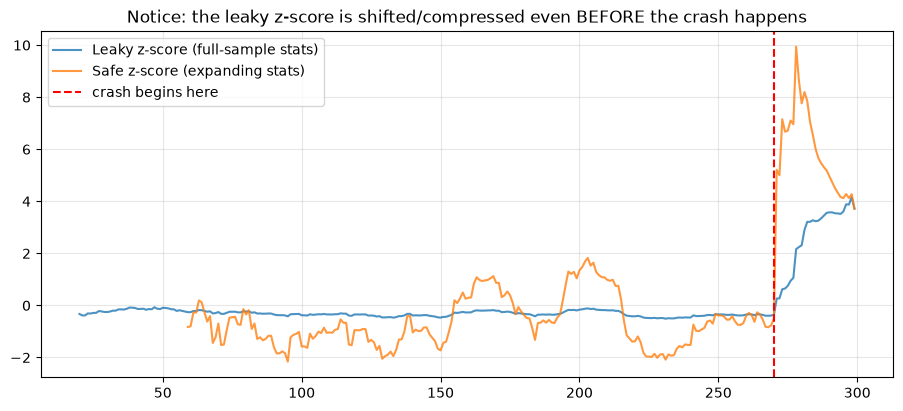

Leaky z-score mean (first 100 obs, pre-crash): -0.239
Safe z-score mean (first 100 obs, pre-crash):  -0.9411


In [24]:
# Demonstrating the z-score leak concretely with a toy "crash"
np.random.seed(7)
n = 300
calm = np.random.normal(0.0005, 0.006, n - 30)
crash = np.random.normal(-0.01, 0.04, 30)   # a violent regime at the END of the sample
toy_returns = pd.Series(np.concatenate([calm, crash]))

toy_vol = toy_returns.rolling(21).std() * np.sqrt(252)

# LEAKY: full-sample stats are influenced by the crash, even for EARLY observations
leaky_z = (toy_vol - toy_vol.mean()) / toy_vol.std()

# CORRECT: expanding stats only see what existed up to that point in time
safe_mean = toy_vol.expanding(min_periods=40).mean()
safe_std = toy_vol.expanding(min_periods=40).std()
safe_z = (toy_vol - safe_mean) / safe_std

fig, ax = plt.subplots()
ax.plot(leaky_z, label="Leaky z-score (full-sample stats)", alpha=0.8)
ax.plot(safe_z, label="Safe z-score (expanding stats)", alpha=0.8)
ax.axvline(n - 30, color="red", ls="--", label="crash begins here")
ax.legend()
ax.set_title("Notice: the leaky z-score is shifted/compressed even BEFORE the crash happens")
plt.show()

print("Leaky z-score mean (first 100 obs, pre-crash):", round(leaky_z.iloc[:100].mean(), 4))
print("Safe z-score mean (first 100 obs, pre-crash): ", round(safe_z.iloc[:100].mean(), 4))


Notice the leaky series is systematically distorted in the *pre-crash* period purely because a crash exists *later* in the dataset that the "leaky" calculation already knows about. A model trained on the leaky feature would, in effect, have advance warning that volatility eventually spikes — something it could never know in live trading.

### The fix, as a principle

> **At every point in time `t`, every number in your dataset must be computable using only information dated `≤ t`.**

This single sentence is the entire content of Section 8 (Walk-Forward Validation), just operationalized as a concrete training procedure.


---
## 8. Walk-Forward Validation — Train/Test Splits That Respect Time

Standard k-fold cross-validation (randomly splitting data into folds) is **wrong** for time series. It violates the principle from Section 7 because random folds let "future" data train a model that's tested on "past" data. Walk-forward validation is the time-series-correct alternative, and it's explicitly listed as a project goal ("Build a Walk-Forward Validation Harness").

### The core idea

Instead of one random split, you create a *sequence* of train/test splits that all slide forward in time:

```
Fold 1: train [████████░░░░░░░░░░░░░░░░░░░░░░░░░░░░] test [░░░░████░░░░░░░░░░░░░░░░░░░░░░░░░░░░]
Fold 2: train [████████████░░░░░░░░░░░░░░░░░░░░░░░░] test [░░░░░░░░░░░░████░░░░░░░░░░░░░░░░░░░░]
Fold 3: train [████████████████░░░░░░░░░░░░░░░░░░░░] test [░░░░░░░░░░░░░░░░░░░░████░░░░░░░░░░░░]
...
```

Each fold: fit ONLY on the training window, evaluate ONLY on the test window immediately after it, then slide both windows forward. Two flavors:

- **Expanding window**: training set grows each fold (always starts at the same point, end moves forward). Uses all available history each time — good when you believe more data always helps.
- **Rolling window**: training set is a fixed size that slides forward (both start and end move). Good when older data may reflect an obsolete regime and could actively hurt the fit ("regime drift").

For an HMM specifically, **re-fit the HMM separately within each fold**, using only that fold's training data. Never fit the HMM once on the full dataset and then split — that's the exact leak from Section 7.


In [25]:
def expanding_walk_forward_splits(n_obs, n_splits=5, min_train_size=252, test_size=63):
    """
    Yields (train_idx, test_idx) tuples for expanding-window walk-forward validation.

    n_obs:          total number of observations
    n_splits:       how many train/test folds to produce
    min_train_size: minimum size of the first training window (in observations)
    test_size:      size of each test window
    """
    splits = []
    start_test = min_train_size
    for i in range(n_splits):
        train_idx = np.arange(0, start_test)
        test_idx = np.arange(start_test, min(start_test + test_size, n_obs))
        if len(test_idx) == 0:
            break
        splits.append((train_idx, test_idx))
        start_test += test_size
    return splits


# Demonstration
n_obs = len(spy)
splits = expanding_walk_forward_splits(n_obs, n_splits=6, min_train_size=500, test_size=126)

for i, (train_idx, test_idx) in enumerate(splits):
    print(f"Fold {i+1}: train = obs[{train_idx[0]}:{train_idx[-1]}]  "
          f"({spy.index[train_idx[0]].date()} to {spy.index[train_idx[-1]].date()})  |  "
          f"test = obs[{test_idx[0]}:{test_idx[-1]}]  "
          f"({spy.index[test_idx[0]].date()} to {spy.index[test_idx[-1]].date()})")


Fold 1: train = obs[0:499]  (2015-01-05 to 2016-12-27)  |  test = obs[500:625]  (2016-12-28 to 2017-06-28)
Fold 2: train = obs[0:625]  (2015-01-05 to 2017-06-28)  |  test = obs[626:751]  (2017-06-29 to 2017-12-27)
Fold 3: train = obs[0:751]  (2015-01-05 to 2017-12-27)  |  test = obs[752:877]  (2017-12-28 to 2018-06-28)
Fold 4: train = obs[0:877]  (2015-01-05 to 2018-06-28)  |  test = obs[878:1003]  (2018-06-29 to 2018-12-28)
Fold 5: train = obs[0:1003]  (2015-01-05 to 2018-12-28)  |  test = obs[1004:1129]  (2018-12-31 to 2019-07-01)
Fold 6: train = obs[0:1129]  (2015-01-05 to 2019-07-01)  |  test = obs[1130:1255]  (2019-07-02 to 2019-12-30)


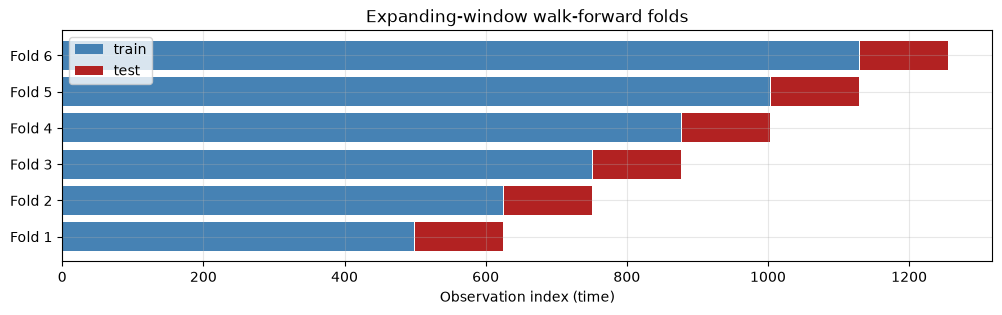

In [26]:
# Visualize the fold structure
fig, ax = plt.subplots(figsize=(12, 3))
for i, (train_idx, test_idx) in enumerate(splits):
    ax.barh(i, train_idx[-1] - train_idx[0], left=train_idx[0], color="steelblue", label="train" if i == 0 else "")
    ax.barh(i, test_idx[-1] - test_idx[0], left=test_idx[0], color="firebrick", label="test" if i == 0 else "")
ax.set_yticks(range(len(splits)))
ax.set_yticklabels([f"Fold {i+1}" for i in range(len(splits))])
ax.set_xlabel("Observation index (time)")
ax.set_title("Expanding-window walk-forward folds")
ax.legend(loc="upper left")
plt.show()


### Why re-fitting matters: a sketch of the correct loop

```python
for train_idx, test_idx in splits:
    train_data = features.iloc[train_idx]
    test_data  = features.iloc[test_idx]

    # 1. Compute normalization stats ONLY on train_data
    mu, sigma = train_data.mean(), train_data.std()
    train_scaled = (train_data - mu) / sigma
    test_scaled  = (test_data  - mu) / sigma   # test uses TRAIN's mu/sigma, never its own

    # 2. Fit the HMM ONLY on train_scaled
    model = hmm.GaussianHMM(n_components=3, covariance_type="full")
    model.fit(train_scaled)

    # 3. Predict regimes on test_scaled using the ALREADY-FITTED model
    test_regimes = model.predict(test_scaled)

    # 4. Evaluate strategy performance on test_idx ONLY, using test_regimes
    #    ... (apply your dynamic constraint mapping here, compute Sharpe etc.)
```

Notice step 1: the test set is transformed using statistics learned **only** from the training set. This is the time-series-correct analogue of `sklearn`'s `scaler.fit(X_train)` then `scaler.transform(X_test)` pattern — same principle, just made explicit because `hmmlearn` doesn't enforce it for you.


### Try it
Using the `expanding_walk_forward_splits` function above, write a loop that, for each fold, computes the **training-set-only** mean and std of `mom_21d` and `vol_21d`, applies that to z-score both train and test slices, and prints the resulting test-set z-score range for each fold. Confirm the train-derived stats don't perfectly match what you'd get from a full-sample z-score (this is your "I actually avoided the leak" check).


In [27]:
# Your code here


---
## 9. ML Primer - From Hidden Markov Models to PyTorch

The capstone's core model is a **Hidden Markov Model (HMM)**, broader tech stack implies you should be comfortable with the ML ecosystem beyond just `hmmlearn` hence the PyTorch primer at the end of this section, useful if you extend the project (e.g. a neural regime classifier, or an LSTM-based feature extractor).

### 9.1 What an HMM actually models

An HMM assumes there's a **hidden state** (the market regime - Bull/Bear/Crisis) that you can't observe directly, but which generates **observable** data (your returns, volatility, momentum features) according to state-specific probability distributions. Two pieces:

- **Transition matrix** — probability of moving from one hidden state to another between consecutive time steps. This encodes regime *persistence* (in practice, regimes are usually "sticky" — the diagonal of this matrix tends to be high).
- **Emission distributions** — for each hidden state, a probability distribution (typically Gaussian, possibly multivariate) over what the observed features look like *given* you're in that state.

Fitting an HMM means estimating both pieces from data using the **Baum-Welch algorithm** (an EM-style procedure) — `hmmlearn` does this for you via `.fit()`. Once fit, the **Viterbi algorithm** finds the single most likely *sequence* of hidden states given the observed data — this is what `.predict()` calls under the hood, and it's distinct from just picking the most-likely-state-at-each-timestep independently (Viterbi accounts for transition probabilities across the whole sequence, not just one timestep at a time).


In [28]:
if HMM_OK:
    from hmmlearn import hmm

    # Build a small, clean feature set for demonstration
    feat_df = spy[["log_ret", "vol_21d"]].dropna().copy()
    feat_df["mom_21d"] = spy["mom_21d"]
    feat_df = feat_df.dropna()

    X = feat_df[["log_ret", "vol_21d", "mom_21d"]].values

    # NOTE: fitting on the FULL series here is for demonstration of the API only.
    # In the actual project, this fit call must happen INSIDE each walk-forward
    # fold's training data, never on the full dataset (Section 7-8).
    model = hmm.GaussianHMM(n_components=3, covariance_type="diag",
                              n_iter=200, random_state=42)
    model.fit(X)

    hidden_states = model.predict(X)   # this calls Viterbi internally
    feat_df["state"] = hidden_states

    print("Transition matrix:\n", np.round(model.transmat_, 3))
    print("\nMean feature values per state (log_ret, vol_21d, mom_21d):\n",
          np.round(model.means_, 4))
    print("\nState counts:\n", feat_df["state"].value_counts())
else:
    print("Skipping - hmmlearn not installed")


d:\Summer Of Quant'26\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "d:\Summer Of Quant'26\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
                         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "d:\Summer Of Quant'26\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\Vatsh Van\AppData\Local\Programs\Python\Python311\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^

Transition matrix:
 [[0.983 0.002 0.015]
 [0.034 0.966 0.   ]
 [0.011 0.    0.989]]

Mean feature values per state (log_ret, vol_21d, mom_21d):
 [[ 1.000e-04  2.046e-01 -1.500e-03]
 [-1.200e-03  5.545e-01 -5.890e-02]
 [ 8.000e-04  9.400e-02  2.220e-02]]

State counts:
 state
2    1280
0     899
1      63
Name: count, dtype: int64


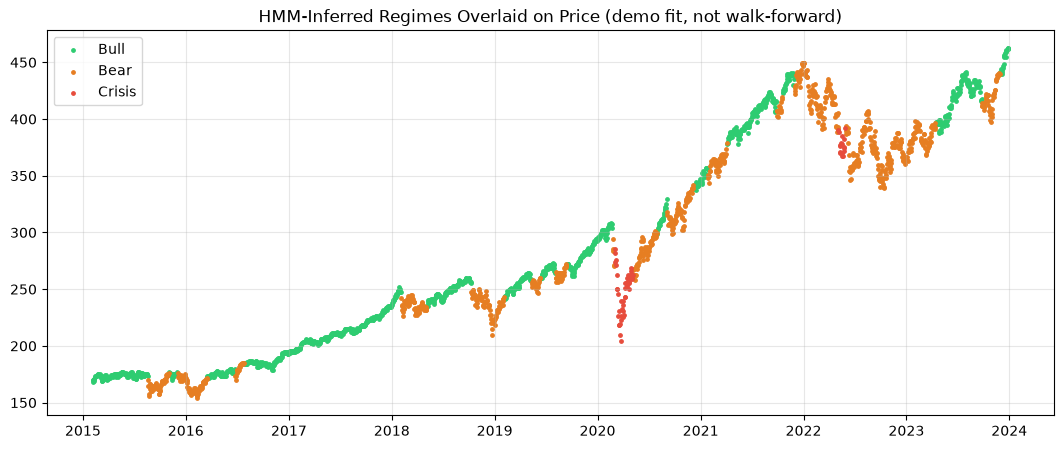

In [29]:
if HMM_OK:
    # Map states to interpretable labels by inspecting their mean volatility
    # (highest avg vol -> Crisis, lowest -> Bull, middle -> Bear). This is a common
    # post-hoc labeling heuristic since HMM state indices (0,1,2) are arbitrary.
    state_vol = feat_df.groupby("state")["vol_21d"].mean().sort_values()
    label_map = {state_vol.index[0]: "Bull", state_vol.index[1]: "Bear", state_vol.index[2]: "Crisis"}
    feat_df["regime_label"] = feat_df["state"].map(label_map)

    fig, ax = plt.subplots(figsize=(13, 5))
    colors = {"Bull": "#2ecc71", "Bear": "#e67e22", "Crisis": "#e74c3c"}
    for label, color in colors.items():
        mask = feat_df["regime_label"] == label
        ax.scatter(feat_df.index[mask], spy.loc[feat_df.index[mask], "close"],
                   s=6, color=color, label=label)
    ax.legend()
    ax.set_title("HMM-Inferred Regimes Overlaid on Price (demo fit, not walk-forward)")
    plt.show()


### 9.2 Why `n_components` and `covariance_type` matter

- `n_components=3` is a modeling *choice*, not something the HMM discovers - it directly corresponds to your project's goal of detecting Bull/Bear/Crisis. Too few states under-discriminates; too many states can produce regimes that aren't economically meaningful (overfitting to noise).
- `covariance_type`: `"diag"` assumes features are uncorrelated within a state (faster, fewer parameters, less overfitting risk with limited data); `"full"` allows feature correlations within a state (more expressive, needs more data to fit reliably). With only a handful of features and a few thousand daily observations, start with `"diag"` or `"tied"` before reaching for `"full"`.

### 9.3 scikit-learn touchpoints

You'll use `scikit-learn` mainly for utilities around the HMM workflow — train/test index management, metrics, and possibly a baseline supervised classifier to sanity-check the HMM against. A few patterns worth knowing:


In [30]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# StandardScaler is the sklearn equivalent of manual z-scoring (Section 4.4) -
# same leak risk applies: ALWAYS .fit() on train only, .transform() on test.
scaler = StandardScaler()
# Correct pattern (illustrative, using all data as "train" here for the demo only):
X_scaled = scaler.fit_transform(X)
print("Scaled feature means (should be ~0):", X_scaled.mean(axis=0).round(4))
print("Scaled feature stds (should be ~1): ", X_scaled.std(axis=0).round(4))

# silhouette_score is a generic clustering quality metric you can use as a SECONDARY
# sanity check on your HMM states (treating them like cluster labels) - not a replacement
# for proper walk-forward backtested evaluation, just a diagnostic.
if HMM_OK:
    score = silhouette_score(X_scaled, hidden_states)
    print(f"\nSilhouette score of HMM states (diagnostic only): {score:.3f}")


Scaled feature means (should be ~0): [0. 0. 0.]
Scaled feature stds (should be ~1):  [1. 1. 1.]

Silhouette score of HMM states (diagnostic only): 0.269


### 9.4 PyTorch Primer

The core capstone doesn't strictly require PyTorch - `hmmlearn` handles the HMM. But you should be comfortable building and training a small neural net, in case you extend the project (e.g., replacing the hand-built feature set with a learned representation, or building a regime classifier as a supervised alternative to compare against the HMM). This is a minimal, complete primer: tensors, a simple feedforward network, and a training loop.


In [34]:
if TORCH_OK:
    import torch
    import torch.nn as nn
    import torch.optim as optim

    torch.manual_seed(42)

    # --- Tensors are PyTorch's version of numpy arrays, with autograd support ---
    x = torch.tensor([1.0, 2.0, 3.0], requires_grad=True)
    y = (x ** 2).sum()
    y.backward()
    print("x:", x)
    print("dy/dx:", x.grad)   # autograd computed this automatically
else:
    print("Skipping - torch not installed")


x: tensor([1., 2., 3.], requires_grad=True)
dy/dx: tensor([2., 4., 6.])


RegimeClassifier(
  (net): Sequential(
    (0): Linear(in_features=3, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=3, bias=True)
  )
)


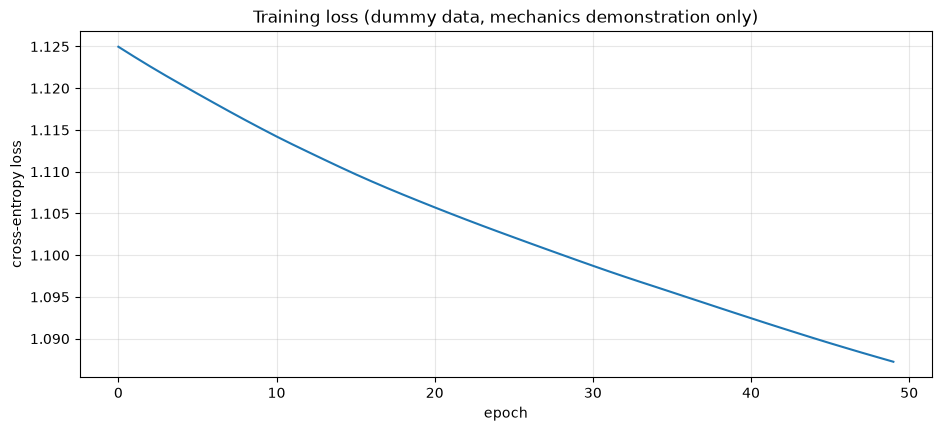

In [35]:
if TORCH_OK:
    # --- A minimal feedforward classifier: predict regime label from features ---
    # (Supervised alternative/sanity-check to the unsupervised HMM - you'd need
    # SOME ground-truth-ish labels to train this, e.g. NBER recession dates as a
    # rough proxy for "Crisis", or your hand-coded rule-based regimes from Section 5.)

    class RegimeClassifier(nn.Module):
        def __init__(self, n_features, n_regimes):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(n_features, 16),
                nn.ReLU(),
                nn.Linear(16, 8),
                nn.ReLU(),
                nn.Linear(8, n_regimes),   # raw logits - softmax applied inside the loss
            )

        def forward(self, x):
            return self.net(x)

    n_features = 3
    n_regimes = 3
    model_nn = RegimeClassifier(n_features, n_regimes)
    print(model_nn)

    # dummy data just to demonstrate the training loop mechanics
    X_dummy = torch.randn(200, n_features)
    y_dummy = torch.randint(0, n_regimes, (200,))

    optimizer = optim.Adam(model_nn.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()

    losses = []
    for epoch in range(50):
        optimizer.zero_grad()
        logits = model_nn(X_dummy)
        loss = loss_fn(logits, y_dummy)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    fig, ax = plt.subplots()
    ax.plot(losses)
    ax.set_title("Training loss (dummy data, mechanics demonstration only)")
    ax.set_xlabel("epoch"); ax.set_ylabel("cross-entropy loss")
    plt.show()


**Important caveat:** the loop above trains on `torch.randn` dummy data purely to demonstrate the mechanics (`zero_grad` → `forward` → `loss` → `backward` → `step`). If you build a real PyTorch classifier for this project, the same walk-forward discipline from Section 8 applies - fit (train) only on a training fold, evaluate only on the held-out test fold, never shuffle time-ordered data into random batches without first respecting a strict time-based split.

### Try it
1. If `hmmlearn` is installed: refit the HMM demo above using `covariance_type="full"` instead of `"diag"` and compare the resulting `model.means_` and state counts — does the regime split change much?
2. If `torch` is installed: modify `RegimeClassifier` to take 5 input features instead of 3, and add a `Dropout(0.2)` layer between the two hidden layers — explain in a markdown cell why dropout might help if you eventually train this on real (not dummy) data with limited samples.


In [ ]:
# Your code here
